
Lattice-physics (PWR fuel assembly neutronics simulation results)

In [1]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
# Uyarıları kapatma
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# Grafik teması ayarları
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print(f"python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.1
Platform: Windows-11-10.0.26200-SP0
seaborn: 0.13.2
pandas: 3.0.5
numpy: 2.5.1
sklearn: 1.9.0


In [ ]:
# 1. Veri Setini Yükleme 
df_raw = pd.read_csv('raw.csv', sep=r'\s+', header=None)

# İlk sütun hedef değişken (y), diğerleri bağımsız değişkenler (X)
X_reg = df_raw.iloc[:, 1:]
y_reg = df_raw.iloc[:, 0]

print("\nVeri Boyutu (Satır, Sütun):", df_raw.shape)


Veri Boyutu (Satır, Sütun): (24000, 41)


In [5]:
# 2. Eğitim ve Test Kümesine Ayırma
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

print(f"Eğitim seti boyutu: {Xr_train.shape[0]}")
print(f"Test seti boyutu: {Xr_test.shape[0]}")

Eğitim seti boyutu: 19200
Test seti boyutu: 4800


In [ ]:
# 3. Modellerin Kurulması
baseline = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)
linear = make_pipeline(StandardScaler(), LinearRegression()).fit(Xr_train, yr_train)
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xr_train, yr_train)
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.0001)).fit(Xr_train, yr_train)

In [7]:
# 4. Regresyon Raporu Fonksiyonu
def regresyon_raporu(model, X, y, ad):
    tahmin = model.predict(X)
    return {
        "Model": ad,
        "MAE": mean_absolute_error(y, tahmin),
        "MSE": mean_squared_error(y, tahmin),
        "RMSE": np.sqrt(mean_squared_error(y, tahmin)),
        "R2": r2_score(y, tahmin)
    }

In [8]:
sonuc = pd.DataFrame([
    regresyon_raporu(baseline, Xr_test, yr_test, "Baseline"),
    regresyon_raporu(linear, Xr_test, yr_test, "Doğrusal"),
    regresyon_raporu(ridge, Xr_test, yr_test, "Ridge"),
    regresyon_raporu(lasso, Xr_test, yr_test, "Lasso")
]).set_index("Model").round(4)

print("\n--- Model Performans Raporu ---")
print(sonuc)


--- Model Performans Raporu ---
             MAE     MSE    RMSE      R2
Model                                   
Baseline  0.0142  0.0003  0.0178 -0.0000
Doğrusal  0.0015  0.0000  0.0020  0.9877
Ridge     0.0015  0.0000  0.0020  0.9877
Lasso     0.0016  0.0000  0.0021  0.9859


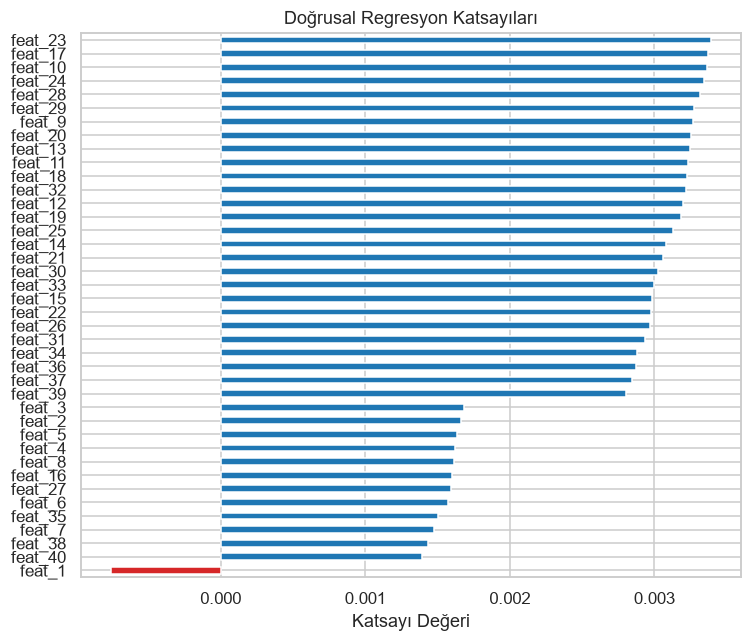

In [9]:
# Doğrusal regresyon katsayı grafiği
linear_model = linear.named_steps['linearregression']
katsayilar = pd.Series(linear_model.coef_, index=[f"feat_{i}" for i in range(1, X_reg.shape[1]+1)]).sort_values()

plt.figure(figsize=(7, 6))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal Regresyon Katsayıları")
plt.xlabel("Katsayı Değeri")
plt.tight_layout()
plt.show()

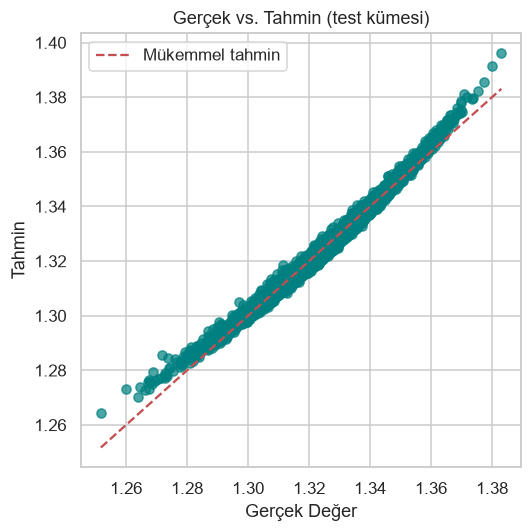

In [10]:
# Gerçek vs Tahmin (Test Kümesi) grafiği
tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.7, color="teal")
lim = [yr_test.min(), yr_test.max()]
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()